In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##DEFINIÇÃO DO DATASET##
df = pd.read_csv("Bike Sharing Dataset.csv")


##INICIO DE TRADUÇÃO##

##COLUNAS##
df = df.rename(columns={
    "yr": "Ano",
    "mnth": "Mês",
    "dteday": "Data",
    "season": "Estação",
    "hr": "Hora",
    "holiday": "Feriado",
    "weekday": "Dia da Semana",
    "workingday": "Dia Útil",
    "weathersit": "Clima",
    "temp": "Temperatura",
    "atemp": "Sensação Térmica",
    "hum": "Umidade",
    "windspeed": "Velocidade do Vento",
    "casual": "Usuários Casuais",
    "registered": "Usuários Registrados",
    "cnt": "Total de Aluguéis"
})

##MUDANÇA DE TIPO DE DADO DA COLUNA DATA E NOMEANDO ANOS##
df["Data"] = pd.to_datetime(df["Data"], dayfirst=True)


##TRADUÇÃO DE DADOS DAS COLUNAS##
df["Mês"] = df["Mês"].replace({
    "january": "janeiro",
    "february": "fevereiro",
    "march": "março",
    "april": "abril",
    "may": "maio",
    "june": "junho",
    "july": "julho",
    "august": "agosto",
    "september": "setembro",
    "october": "outubro",
    "november": "novembro",
    "december": "dezembro"
})

df["Estação"] = df["Estação"].replace({
    "spring": "primavera",
    "summer": "verão",
    "autumn": "outono",
    "winter": "inverno"
})

df["Feriado"] = df["Feriado"].replace({
    "no": "não",
    "yes": "sim"
})

df["Dia da Semana"] = df["Dia da Semana"].replace({
    "monday": "segunda-feira",
    "tuesday": "terça-feira",
    "wednesday": "quarta-feira",
    "thursday": "quinta-feira",
    "friday": "sexta-feira",
    "saturday": "sábado",
    "sunday": "domingo"
})

df["Dia Útil"] = df["Dia Útil"].replace({
    "no": "não",
    "yes": "sim"
})

df["Clima"] = df["Clima"].replace({
    "clear": "céu limpo",
    "misty": "nebuloso",
    "light rain": "chuva leve",
    "heavy rain": "chuva forte"
})
##FIM DA TRADUÇÃO##

clima_total = df.groupby("Clima")["Total de Aluguéis"].sum().reset_index()

##DROP DE COLUNAS DESNECESSÁRIAS##
df = df.drop(columns=["instant"])
df = df.drop(columns=["Ano"])
df = df.drop(columns=["Mês"])

##CRIAÇÃO DO DATASET TRATADO##
df.to_csv("bike_tratado.csv",index=False)


In [ ]:
##3 PICO POR ANO E HORA##
pico_horario = df.groupby([df["Data"].dt.year,"Hora"])["Total de Aluguéis"].sum()
pico_horario.sort_values(ascending=False).reset_index().head(15)

,Data,Hora,Total de Aluguéis
0,2012,17,209228
1,2012,18,192787
2,2012,8,165534
3,2012,16,142126
4,2012,19,140987
5,2011,17,127632
6,2011,18,116985
7,2012,13,115580
8,2012,12,115216
9,2012,15,114559


In [ ]:
##SEM VALORES AUSENTES
print(df.isnull().sum())

Data                    0
Estação                 0
Hora                    0
Feriado                 0
Dia da Semana           0
Dia Útil                0
Clima                   0
Temperatura             0
Sensação Térmica        0
Umidade                 0
Velocidade do Vento     0
Usuários Casuais        0
Usuários Registrados    0
Total de Aluguéis       0
dtype: int64


In [ ]:
##EXPLICATIVO##
total_casuais = df["Usuários Casuais"].sum()
total_casuais

np.int64(620017)

In [ ]:
##EXPLICATIVO##
total_registrados = df["Usuários Registrados"].sum()
total_registrados

np.int64(2672662)

In [ ]:
##CONFESSO PREGUIÇA DE ESCREVER##
total_ano_mes=df.groupby([df["Data"].dt.year,df["Data"].dt.month])["Total de Aluguéis"].sum()
total_ano_mes


Data  Data
2011  1        38189
      2        48215
      3        64045
      4        94870
      5       135821
      6       143512
      7       141341
      8       136691
      9       127418
      10      123511
      11      102167
      12       87323
2012  1        96744
      2       103137
      3       164875
      4       174224
      5       195865
      6       202830
      7       203607
      8       214503
      9       218573
      10      198841
      11      152664
      12      123713
Name: Total de Aluguéis, dtype: int64

In [38]:
alugueis_por_ano = df.groupby(df["Data"].dt.year)["Total de Aluguéis"].sum().reset_index()
alugueis_por_ano

,Data,Total de Aluguéis
0,2011,1243103
1,2012,2049576


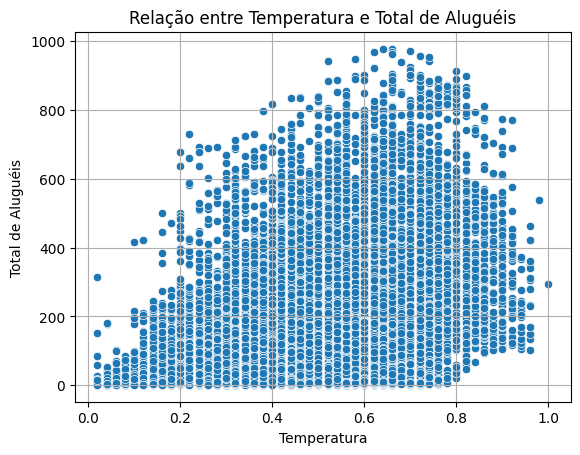

In [43]:
sns.scatterplot(data=df, x="Temperatura", y="Total de Aluguéis")
plt.title("Relação entre Temperatura e Total de Aluguéis")
plt.grid(True)
plt.show()

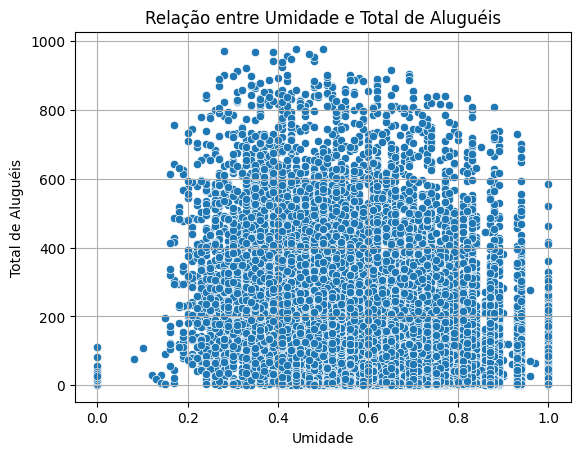

In [44]:
sns.scatterplot(data=df, x="Umidade", y="Total de Aluguéis")
plt.title("Relação entre Umidade e Total de Aluguéis")
plt.grid(True)
plt.show()

In [49]:
media_alugueis_dia = df.groupby("Data")["Total de Aluguéis"].sum().mean()
print(media_alugueis_dia)

4504.3488372093025


    Data  Hora  Total de Aluguéis
0   2011     0              15540
1   2011     1               9558
2   2011     2               6661
3   2011     3               3441
4   2011     4               1817
5   2011     5               5157
6   2011     6              20801
7   2011     7              56930
8   2011     8              95467
9   2011     9              59486
10  2011    10              47511
11  2011    11              56598
12  2011    12              69198
13  2011    13              69339
14  2011    14              66482
15  2011    15              68590
16  2011    16              85622
17  2011    17             127632
18  2011    18             116985
19  2011    19              85802
20  2011    20              62818
21  2011    21              48875
22  2011    22              37677
23  2011    23              25116
24  2012     0              23590
25  2012     1              14606
26  2012     2               9691
27  2012     3               4733
28  2012     4

<Axes: xlabel='Data', ylabel='Total de Aluguéis'>

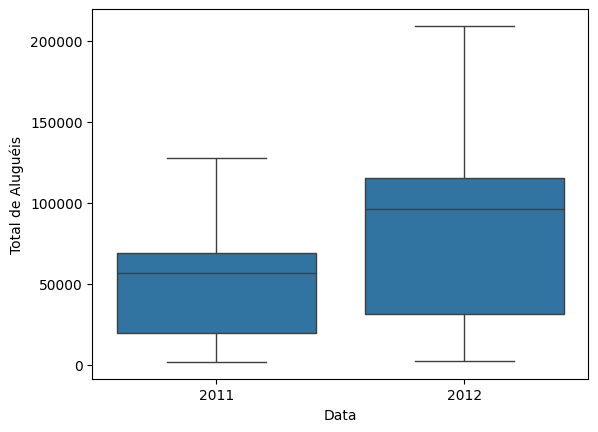

In [111]:
media_por_hora = df.groupby([df["Data"].dt.year,"Hora"])["Total de Aluguéis"].sum().reset_index()
print(media_por_hora)
sns.boxplot(y=media_por_hora["Total de Aluguéis"],x=media_por_hora["Data"])